# NFL Playoff Contention - Historical Analysis (2010 to 2024)

## Hypothesis

More franchises in playoff contention deep into the season result in more engaged fan bases which results in higher TV viewership, which leads to greater future advertising revenue for the NFL. If schedule design can sustain contention deeper into the season, it is a lever for increasing league-wide TV ratings and League revenue.

This notebook establishes the **historical baseline**: how many teams have been mathematically alive for a playoff spot during the final seven weeks of each season from 2010–2024? We answer this using a **Mixed-Integer Program (MIP)** that computes the minimum wins a team would need to make the playoffs given the remaining schedule. This is mathematical elimination in the classic sense.

### LP Approximation Note

The MIP ignores tie-breaker rules (head-to-head, conference record, etc.). A team is "eliminated" only when it is mathematically impossible for it to finish with enough wins to claim a playoff spot, regardless of tie-breakers. This means we **undercount** eliminations - we are conservative. All seasons are evaluated under the same approximation, so the comparison is apples-to-apples across years.

Beta (wild card spots per conference) is fixed at **β = 3** throughout all seasons, even though β = 2 was in effect before 2020. This creates a uniform comparator: how many teams were in contention under the current playoff structure? Applying current rules retroactively is intentional - we are measuring schedule parity, not tracking the effects of the 2020 rule change.

## MIP Formulation

The elimination check for division $D_k$ in conference $C_{l'}$ asks: *what is the minimum number of wins needed for some team in $D_k$ to make the playoffs, given the remaining games?* If this minimum exceeds a team's maximum achievable win total, it is eliminated.

**Variables:**
- $i, j$: teams (indexed over conferences/divisions), $L$: all 32 NFL teams, $C_{l'}$: 16-team conference, $D_k$: 4-team division  
- $g_{ij}$: 1 if game $(i,j)$ has not yet been played, 0 otherwise  
- $x_{ij} \in \mathbb{R}_+$: games won by team $i$ against team $j$ (over remaining schedule)  
- $\alpha_i \in \{0,1\}$: 1 if team $i$ makes the playoffs  
- $\beta$: wild card spots per conference (fixed at 3)  
- $u^D$: wins required to win the division; $u^W$: wins required for a wild card spot  
- $\delta \in \{0,1\}$: selects which threshold ($u^D$ or $u^W$) is binding  
- $u = \min(u^D, u^W)$: minimum wins to make the playoffs from division $D_k$  
- $M = 17$: big-M (total regular season games per team)

**Objective:**
$$\min \; u \tag{2.18}$$

**Subject to:**

$$x_{ij} + x_{ji} = g_{ij}, \quad \forall i \in C_{l'}, \; j \in L \tag{2.19}$$

$$u^D \geq w_i + \sum_{j \in L} x_{ij}, \quad \forall i \in D_k \tag{2.20}$$

$$\sum_{i \in D_k} \alpha_i \geq 1, \quad \forall k \in C'_{l'} \tag{2.21}$$

$$\sum_{i \in C_{l'}} \alpha_i = \beta + 3 \tag{2.22}$$

$$w_i + \sum_{j \in L} x_{ij} \leq u^W + M\alpha_i, \quad \forall i \in C_{l'} \tag{2.23}$$

$$u + M\delta \geq u^D \tag{2.24}$$

$$u + M(1 - \delta) \geq u^W \tag{2.25}$$

$$\alpha_i, \delta \in \{0,1\} \tag{2.26}$$

$$u, u^W, u^D \in \mathbb{Z}_+ \tag{2.27}$$

$$x_{ij} \in \mathbb{R}_+ \tag{2.28}$$

Constraint (2.19) ensures each remaining game is allocated exactly one winner. (2.20) forces the division threshold above every division team's projected wins. (2.21)–(2.22) enforce the playoff bracket structure: each division contributes at least one team, and exactly $\beta + 3 = 7$ teams qualify. (2.23) bounds non-qualifiers' wins below the wild card threshold. (2.24)–(2.25) implement $u = \min(u^D, u^W)$ via the binary switch $\delta$.

## Data

In [ ]:
import sys; sys.path.append('..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

from utils import load_canonical_matchups, load_season_games
from lp_solver import (
    elimination_lp, ALL_DIVISIONS, DIVISION_CONFERENCES, AFC, NFC
)

load_dotenv(r'...\nfl_data_pipeline\.env')
engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)
print("DB connected")

DB connected


In [2]:
# Validate 2022 matchups as a sanity check
matchups_2022 = load_canonical_matchups(engine, 2022)
print(f"2022 matchups: {len(matchups_2022)} (271 — BUF-CIN Week 17 cancelled)")

# Show a sample
sample_df = pd.DataFrame(matchups_2022[:10], columns=['away', 'home'])
display(sample_df)

2022 matchups: 271 (271 — BUF-CIN Week 17 cancelled)


,away,home
0,BUF,LAR
1,NO,ATL
2,CLE,CAR
3,SF,CHI
4,PIT,CIN
5,IND,HOU
6,PHI,DET
7,JAX,WSH
8,NE,MIA
9,BAL,NYJ


## Elimination LP Implementation

The `elimination_lp` function is in `lp_solver.py` (one level up from this notebook).

In [ ]:
# Smoke test: end-of-season scenario; verify the LP runs correctly
from lp_solver import AFC_NORTH, AFC_SOUTH, AFC_EAST, AFC_WEST

records_test = {t: [8, 9] for t in AFC + NFC}
records_test['PIT'] = [4, 13]   # mathematically eliminated
records_test['BAL'] = [13, 4]
records_test['CIN'] = [12, 5]
records_test['CLE'] = [11, 6]

matchups_test = list(zip(AFC, AFC[1:])) + list(zip(NFC, NFC[1:]))  # minimal stub
gij_test = np.zeros(len(matchups_test), dtype=int)

eliminated_test = elimination_lp(3, AFC_NORTH, records_test, matchups_test, gij_test, AFC)
assert 'PIT' in eliminated_test, f"Smoke test failed: expected PIT eliminated, got {eliminated_test}"
print(f"Smoke test passed — eliminated: {eliminated_test}")

Smoke test passed — eliminated: ['PIT']


## Historical Contention Analysis (2010 to 2024)

In [ ]:
BETA_VAL = 3
seasons  = list(range(2010, 2025))
x_axis   = list(range(-6, 1))  # relative weeks: -6 = 6 weeks before end, 0 = final week

historical_curves = {}  # {season: np.array of shape (7,)}

for season in tqdm(seasons, desc='Seasons'):
    games_df = load_season_games(engine, season)
    matchups_s = load_canonical_matchups(engine, season)
    canonical_lookup_s = {pair: i for i, pair in enumerate(matchups_s)}
    max_week = int(games_df['week'].max())
    contention_weeks = list(range(max_week - 6, max_week + 1))

    gij = np.ones(len(matchups_s), dtype=int)
    records = {team: [0, 0] for team in (AFC + NFC)}
    curve = np.zeros(7)

    for week in range(1, max_week + 1):
        week_games = games_df[games_df['week'] == week]
        for _, row in week_games.iterrows():
            pair   = (row['away_abbr'], row['home_abbr'])
            winner = row['home_abbr'] if row['home_won'] else row['away_abbr']
            loser  = row['away_abbr'] if row['home_won'] else row['home_abbr']
            records[winner][0] += 1
            records[loser][1]  += 1
            if pair in canonical_lookup_s:
                gij[canonical_lookup_s[pair]] = 0

        if week in contention_weeks:
            elim_count = 0
            for div_idx, division in enumerate(ALL_DIVISIONS):
                conf = AFC if DIVISION_CONFERENCES[div_idx] == 'AFC' else NFC
                eliminated = elimination_lp(
                    BETA_VAL, division, records, matchups_s, gij, conf
                )
                elim_count += len(eliminated)
            col = contention_weeks.index(week)
            curve[col] = 32 - elim_count

    historical_curves[season] = curve
    print(f"{season}: {curve}")

Seasons:   0%|          | 0/15 [00:00<?, ?it/s]

2010: [32. 31. 28. 26. 21. 19. 16.]
2011: [32. 31. 29. 29. 22. 21. 19.]
2012: [32. 32. 30. 25. 25. 20. 14.]
2013: [32. 32. 32. 28. 20. 20. 18.]
2014: [31. 30. 26. 24. 22. 20. 17.]
2015: [32. 32. 31. 28. 23. 16. 14.]
2016: [31. 30. 29. 26. 22. 19. 16.]
2017: [32. 30. 29. 26. 20. 17. 17.]
2018: [32. 32. 30. 29. 21. 16. 14.]
2019: [32. 31. 31. 24. 20. 19. 14.]
2020: [31. 30. 28. 27. 21. 18. 15.]
2021: [32. 32. 28. 28. 24. 19. 18.]
2022: [32. 31. 31. 27. 26. 23. 17.]
2023: [32. 32. 30. 29. 25. 23. 16.]
2024: [32. 28. 25. 23. 20. 18. 15.]


## Results

Each line below shows one season's contention curve: how many teams were mathematically alive for a playoff spot at each of the final 7 weeks. The bold black line is the 2010-2024 mean; the shaded band is ±1 standard deviation.

The x-axis uses weeks relative to season end so curves from 16-game seasons (2010–2020) and 17-game seasons (2021+) are directly comparable.

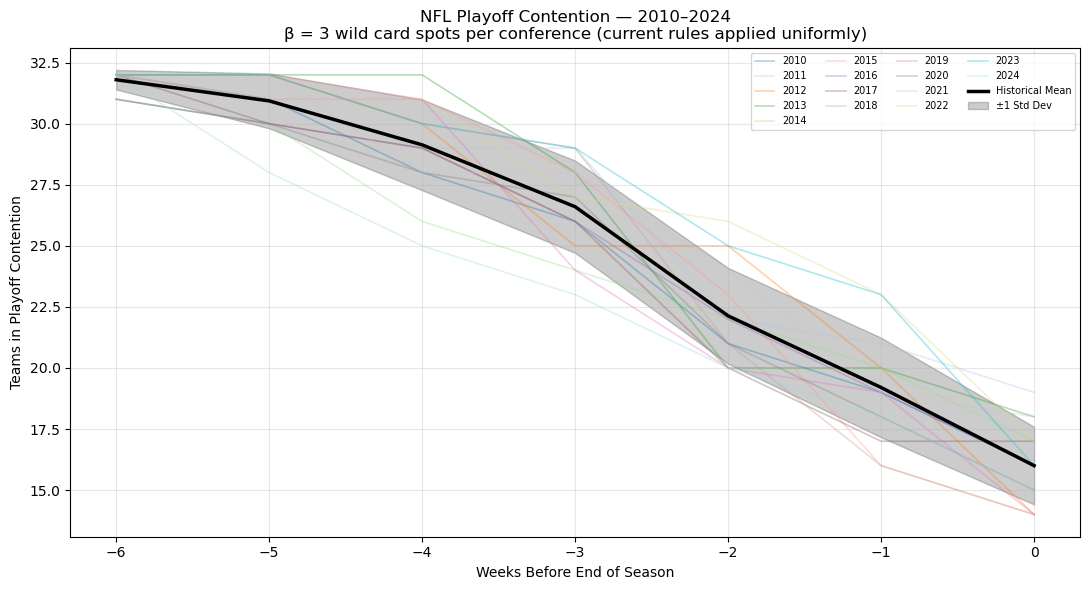

Historical mean saved. Final-week contention: 16.0 ± 1.6 teams


In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
x = list(range(-6, 1))
colors = plt.cm.tab20(np.linspace(0, 1, len(seasons)))

# Individual season lines (faint)
for i, season in enumerate(seasons):
    ax.plot(x, historical_curves[season], color=colors[i],
            alpha=0.35, linewidth=1.2, label=str(season))

# Mean ± std band
mean_curve = np.array([historical_curves[s] for s in seasons]).mean(axis=0)
std_curve  = np.array([historical_curves[s] for s in seasons]).std(axis=0)
ax.plot(x, mean_curve, 'k-', linewidth=2.5, label='Historical Mean')
ax.fill_between(x, mean_curve - std_curve, mean_curve + std_curve,
                alpha=0.2, color='black', label='±1 Std Dev')

ax.set_xlabel('Weeks Before End of Season')
ax.set_ylabel('Teams in Playoff Contention')
ax.set_title('NFL Playoff Contention — 2010–2024\n'
             f'β = {BETA_VAL} wild card spots per conference (current rules applied uniformly)')
ax.set_xticks(x)
ax.legend(fontsize=7, ncol=4)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Save for Notebook B overlay
np.save('../historical_mean_curve.npy', mean_curve)
np.save('../historical_std_curve.npy',  std_curve)
print(f"Historical mean saved. Final-week contention: {mean_curve[-1]:.1f} ± {std_curve[-1]:.1f} teams")

## Conclusions

Several observations stand out from the historical contention curves:

1. **Contention relevent only starting at week 11-12:** Depending on a 16 or 17 game NFL season, 7 weeks out puts us at week 11 or 12 (right around Thanksgiving). The plot shows that it is actually quite rare for teams to be mathematically eliminated before this point in the season, which is surprising and encouraging considering there are low-single digit performing teams every year. 

2. **Outliers:**  There are no obvious outlier seasons in the graph. 2013 starts out as a positive outlier in early contention weeks, but then rapidly declines before falling just above the +1 std band on the final week. 2024 starts out as a negative outlier in the first 4 contention weeks, but then the final 3 weeks fall within the -1 std band. There are no seasons that fall outside of the +-1 std band for the entire 7 weeks. What stands out instead is that the rate of decay is highly variable season to season, although most seasons' contenders on each week fall within the std band. 

3. **Final-week contention:** On the penultimate week of the regular season, the historical mean has approximately 19 teams still alive. So about 13 teams on average are eliminated before the final game of the season.

3. **Motivation:** The 2022 and 2023 seasons each sustain 23 teams in contention through the penultimate week, while 2015 and 2018 only sustain 16. This variance suggests that schedule design and league parity has a real effect - the question is how large.

`bayesian_hierarchical_season_simulator.ipynb` and `playoff_contention_simulated.ipynb` quantifies the effect of parity and schedule optimization respectively on playoff contention: using Bayesian-simulated game outcomes for 2021 run against an algorithmically optimized schedule, we measure the lift in final-week contention relative to this historical mean.

> Note: the schedule optimization algorithm is proprietary and not published in this repo. We do however display the resulting schedule from the algorithm. The purpose of this project is to show Mixed Integer Programming prowess through the elimnation MIP used in this notebook, as well as usecases for uncertainty quantification through Bayesian statistical workflows. 